# 3. Modelagem


Após as etapas de entendimento, preparação e enriquecimento dos dados, e a seleção das variáveis mais relevantes, chegamos à fase de modelagem preditiva. O objetivo desta etapa é construir e avaliar diferentes algoritmos de machine learning capazes de identificar padrões e prever a probabilidade de ocorrência do evento de interesse.

Nesta fase, os dados já tratados são divididos em conjuntos de treino e teste, permitindo ajustar os modelos e validar sua capacidade de generalização.

O resultado esperado é a seleção do modelo mais adequado, equilibrando desempenho preditivo, interpretabilidade e robustez, de modo a gerar previsões confiáveis que possam apoiar a tomada de decisão.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Instalação dos pacotes e importação das bibliotecas

In [2]:
!pip install optuna #framework para otimização e tuning de hiperparâmetros
!pip install category_encoders #Enconding de variáveis categóricas
!pip install catboost #Modelo de gradient boosting

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [3]:
import numpy             as np
import matplotlib.pyplot as plt
import matplotlib        as mpl
import pandas            as pd
import seaborn           as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, ShuffleSplit
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier, \
HistGradientBoostingClassifier,StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, f1_score, make_scorer, accuracy_score, precision_score, recall_score, auc
import optuna
import pickle
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB

Funções auxiliares

In [4]:
# Métricas do modelo

def calculate_metrics(nm_modelo, model, X_train, y_train, X_test, y_test):
    # Fazendo predições
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculando as métricas para o conjunto de treino
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    auc_roc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])

    # Calculando o Índice Gini e Estatística KS para o conjunto de treino
    probabilities_train = model.predict_proba(X_train)[:, 1]
    df_train = pd.DataFrame({'true_labels': y_train, 'predicted_probs': probabilities_train})
    df_train = df_train.sort_values(by='predicted_probs', ascending=False)
    df_train['cumulative_true'] = df_train['true_labels'].cumsum() / df_train['true_labels'].sum()
    df_train['cumulative_false'] = (1 - df_train['true_labels']).cumsum() / (1 - df_train['true_labels']).sum()
    ks_statistic_train = max(abs(df_train['cumulative_true'] - df_train['cumulative_false']))
    gini_index_train = 2 * auc_roc_train - 1

    # Calculando as métricas para o conjunto de teste
    accuracy_test = accuracy_score(y_test, y_test_pred)
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)
    auc_roc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

    # Calculando o Índice Gini e Estatística KS para o conjunto de teste
    probabilities_test = model.predict_proba(X_test)[:, 1]
    df_test = pd.DataFrame({'true_labels': y_test, 'predicted_probs': probabilities_test})
    df_test = df_test.sort_values(by='predicted_probs', ascending=False)
    df_test['cumulative_true'] = df_test['true_labels'].cumsum() / df_test['true_labels'].sum()
    df_test['cumulative_false'] = (1 - df_test['true_labels']).cumsum() / (1 - df_test['true_labels']).sum()
    ks_statistic_test = max(abs(df_test['cumulative_true'] - df_test['cumulative_false']))
    gini_index_test = 2 * auc_roc_test - 1

    # Criando o DataFrame com as métricas calculadas
    metrics_df = pd.DataFrame({
        'Algoritmo': [nm_modelo, nm_modelo],
        'Conjunto': ['Treino', 'Teste'],
        'Acuracia': [accuracy_train, accuracy_test],
        'Precisao': [precision_train, precision_test],
        'Recall': [recall_train, recall_test],
        'AUC_ROC': [auc_roc_train, auc_roc_test],
        'GINI': [gini_index_train, gini_index_test],
        'KS': [ks_statistic_train, ks_statistic_test]
    })
    return metrics_df

def calculate_metrics_train(nm_modelo, X_train, y_train):
    # Fazendo predições
    y_train_prob = X_train.score_fraude
    y_train_pred = (y_train_prob > 0.5).astype(int)

    # Calculando as métricas para o conjunto de treino
    accuracy_train = accuracy_score(y_train, y_train_pred)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    auc_roc_train = roc_auc_score(y_train, y_train_prob)

    # Calculando o Índice Gini e Estatística KS para o conjunto de treino
    probabilities_train = y_train_prob
    df_train = pd.DataFrame({'true_labels': y_train, 'predicted_probs': probabilities_train})
    df_train = df_train.sort_values(by='predicted_probs', ascending=False)
    df_train['cumulative_true'] = df_train['true_labels'].cumsum() / df_train['true_labels'].sum()
    df_train['cumulative_false'] = (1 - df_train['true_labels']).cumsum() / (1 - df_train['true_labels']).sum()
    ks_statistic_train = max(abs(df_train['cumulative_true'] - df_train['cumulative_false']))
    gini_index_train = 2 * auc_roc_train - 1

    # Criando o DataFrame com as métricas calculadas
    metrics_df = pd.DataFrame({
        'Algoritmo': [nm_modelo],
        'Conjunto': ['Treino'],
        'Acuracia': [accuracy_train],
        'Precisao': [precision_train],
        'Recall': [recall_train],
        'AUC_ROC': [auc_roc_train],
        'GINI': [gini_index_train],
        'KS': [ks_statistic_train]
    })
    return metrics_df

def plot_metrics(model, X_train, y_train, X_test, y_test, features):
    plt.figure(figsize=(15, 18))

    # Gráfico de Barras para Taxa do Evento e Importância das Variáveis
    plt.subplot(4, 2, 1)
    event_rate = y_train.mean()
    non_event_rate = 1 - event_rate
    plt.barh(['Não Evento', 'Evento'], [non_event_rate, event_rate], color=['lightsteelblue', 'skyblue'])
    plt.xlabel('Taxa')
    plt.title('Taxa do Evento')

    plt.subplot(4, 2, 2)
    importances = model.feature_importances_
    indices = np.argsort(importances)  # Ordem ascendente
    indices = indices[-10:]  # Considerando apenas as 10 mais importantes
    plt.barh(features[indices], importances[indices], color='skyblue')
    plt.xlabel('Importância')
    plt.title('Importância das Variáveis')

    # Curva ROC para Treino e Teste
    plt.subplot(4, 2, 3)
    for X, y, label in [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')]:
        fpr, tpr, _ = roc_curve(y, model.predict_proba(X)[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')

    # Gráfico de Barras para Gini e KS
    plt.subplot(4, 2, 4)
    metrics = ['Índice Gini', 'Estatística KS']
    for X, y, label in [(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')]:
        probs = model.predict_proba(X)[:, 1]
        df = pd.DataFrame({'true_labels': y, 'predicted_probs': probs})
        df = df.sort_values(by='predicted_probs', ascending=False)
        df['cumulative_true'] = df['true_labels'].cumsum() / df['true_labels'].sum()
        df['cumulative_false'] = (1 - df['true_labels']).cumsum() / (1 - df['true_labels']).sum()
        ks = max(abs(df['cumulative_true'] - df['cumulative_false']))
        gini = 2 * auc(*roc_curve(y, probs)[:2]) - 1
        plt.bar([f'{label}\n{metric}' for metric in metrics], [gini, ks], color='skyblue')
    plt.title('Índice Gini e Estatística KS')

    # Matrizes de Confusão para Treino e Teste
    for i, (X, y, label) in enumerate([(X_train, y_train, 'Treino'), (X_test, y_test, 'Teste')], 5):
        plt.subplot(4, 2, i)
        conf_matrix = confusion_matrix(y, model.predict(X))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Matriz de Confusão - {label}')

    # Histograma do Score para Treino e Teste
    plt.subplot(4, 2, 7)
    plt.hist(model.predict_proba(X_train)[:, 1], bins=30, color='skyblue', edgecolor='black', alpha=0.7, label='Treino')
    plt.xlabel('Score')
    plt.ylabel('Frequência')
    plt.title('Histograma do Score - Treino')
    plt.legend(loc='upper right')

    plt.subplot(4, 2, 8)
    plt.hist(model.predict_proba(X_test)[:, 1], bins=30, color='lightsteelblue', edgecolor='black', alpha=0.7, label='Teste')
    plt.xlabel('Score')
    plt.ylabel('Frequência')
    plt.title('Histograma do Score - Teste')
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

Leitura dos datasets

In [8]:
df_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/02-Data Prep/df_train_full.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/02-Data Prep/df_test_full.csv')

abt_vigente = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/00-Dados/abt_vigente_score.csv')

In [ ]:
abt_vigente.head()

,TRANSACTION_ID,TX_AMOUNT,TX_FRAUD,mean_amount,std_amount,mean_nb_tx_per_day,score_fraude
0,59452,61.51,0,62.262521,31.13126,2.179533,13
1,59592,129.61,0,62.262521,31.13126,2.179533,809
2,60132,96.50,0,62.262521,31.13126,2.179533,762
3,60721,82.19,0,62.262521,31.13126,2.179533,555
4,61033,50.77,0,62.262521,31.13126,2.179533,600


In [9]:
df_train.head()

,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_FRAUD,x_customer_id,y_customer_id,mean_amount,std_amount,...,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_8H,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_24H,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_7D,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_14D,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_2H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_4H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_8H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_24H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_7D,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_14D
0,59452,2021-08-01 03:01:00,0,1133,61.51,0,10.95017,59.768684,62.262521,31.13126,...,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000
1,59592,2021-08-01 05:30:38,0,1138,129.61,0,10.95017,59.768684,62.262521,31.13126,...,1.356321,1.356321,1.356321,1.356321,1.0,0.5,0.500000,0.500000,0.500000,0.500000
2,60132,2021-08-01 10:40:12,0,1530,96.50,0,10.95017,59.768684,62.262521,31.13126,...,1.006536,1.006536,1.006536,1.006536,1.0,1.0,0.333333,0.333333,0.333333,0.333333
3,60721,2021-08-01 15:38:25,0,241,82.19,0,10.95017,59.768684,62.262521,31.13126,...,0.919917,0.888997,0.888997,0.888997,1.0,1.0,0.500000,0.250000,0.250000,0.250000
4,61033,2021-08-01 19:25:30,0,1536,50.77,0,10.95017,59.768684,62.262521,31.13126,...,0.763688,0.603571,0.603571,0.603571,1.0,0.5,0.500000,0.200000,0.200000,0.200000


# 3.1 Preparação dos Dados para Modelagem

Nesta etapa, os dados foram preparados para o treinamento dos modelos de aprendizado de máquina. As variáveis explicativas (X) foram separadas da variável alvo (y), removendo-se colunas identificadoras e atributos que não devem ser utilizados diretamente na modelagem, com o objetivo de evitar vazamento de informação.

Em seguida, o conjunto de dados foi dividido em treino e teste (80/20). As features foram separadas em variáveis categóricas e numéricas, aplicando-se pipelines específicos para cada tipo. As variáveis categóricas foram tratadas com imputação pelo valor mais frequente e Target Encoding, enquanto as variáveis numéricas passaram por imputação pela mediana e padronização com StandardScaler.

O pré-processamento foi encapsulado em um ColumnTransformer e ajustado apenas nos dados de treino, sendo posteriormente aplicado ao conjunto de teste. Como resultado, obtiveram-se os conjuntos X_train_processed e X_test_processed, prontos para a etapa de modelagem.

In [10]:
X = df_train.drop(columns=['TX_FRAUD','TRANSACTION_ID',	'TX_DATETIME',	'CUSTOMER_ID',	'TERMINAL_ID','x_customer_id','y_customer_id','x_terminal_id','y_terminal_id'])
y = df_train['TX_FRAUD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

cat_attributes = X_train.select_dtypes(include='object')
num_attributes = X_train.select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor = ColumnTransformer([
    ('cat', cat_pipe, cat_attributes.columns),
    ('num', num_pipe, num_attributes.columns)
])
preprocesssor = Pipeline(steps=[("preprocessor", preprocessor)])

X_train_processed = pd.DataFrame(preprocesssor.fit_transform(X_train, y_train),columns=X_train.columns)
X_test_processed = pd.DataFrame(preprocesssor.transform(X_test),columns=X_test.columns)

In [11]:
X_train_processed.head()

,TX_AMOUNT,mean_amount,std_amount,mean_nb_tx_per_day,month_reference,PERIODO_DIA,hour_of_day,day_of_week,day_of_month,month,...,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_8H,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_24H,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_7D,RATIO_MEAN_AMOUNT_PER_CUSTOMER_LAST1H_TO_14D,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_2H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_4H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_8H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_24H,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_7D,RATIO_TOTAL_TRANSACTIONS_PER_CUSTOMER_LAST1H_TO_14D
0,0.021826,0.019725,-0.197122,1.241692,1.241692,0.450039,1.422486,-1.090777,-0.486728,0.715921,...,0.002591,-0.426376,-0.991283,-0.776378,0.379072,0.661341,0.986930,-0.651548,-0.094260,-0.250625
1,0.021826,0.019725,-0.402225,0.567883,0.567883,-2.181832,0.714993,-0.695512,1.012278,-0.309685,...,0.002591,0.000172,-1.235326,-1.100386,0.379072,0.661341,0.986930,2.216140,1.121227,1.115472
2,0.022658,0.017819,-0.555295,-0.487752,-0.487752,0.572798,0.007501,0.095018,1.012278,-1.563202,...,-0.649090,-0.056576,-0.605327,-0.610125,0.379072,-1.364632,-1.286620,-0.651548,-0.554672,-0.368682
3,0.021826,0.017427,2.707922,1.651034,1.651034,1.162627,1.422486,-0.300247,1.012278,1.057789,...,0.806277,0.633017,1.270654,1.017755,0.379072,-1.364632,-0.718232,-0.842727,-0.442446,-0.353925
4,0.024280,0.019725,-1.211525,-1.685450,-1.685450,-0.989720,-0.699992,1.478445,0.012941,-0.765509,...,0.002591,0.000172,0.396795,-0.115980,0.379072,0.661341,0.986930,2.216140,0.380540,0.064196


# 3.4. Modelagem

Nesta etapa foi criada uma lista com diferentes algoritmos de classificação — árvore de decisão, regressão logística, random forest, gradient boosting, XGBoost e LightGBM — todos instanciados com parâmetros básicos e random_state para garantir reprodutibilidade. Em seguida, o código percorre cada algoritmo da lista e executa três etapas principais: identifica o nome do modelo, treina o algoritmo nos dados de treino já pré-processados (X_train_processed e y_train) e, por fim, chama uma função de cálculo de métricas para avaliar o desempenho do modelo. Esse processo é importante porque permite comparar diferentes técnicas de machine learning aplicadas ao mesmo conjunto de dados, entendendo qual delas se adapta melhor ao problema, considerando tanto métricas estatísticas quanto potenciais resultados práticos para a detecção de fraude.

In [12]:
# Testar outros modelos

algoritmos = [DecisionTreeClassifier(criterion='gini',random_state=0),
            LogisticRegression(solver='liblinear',random_state=0),
            RandomForestClassifier(random_state=0),
            GradientBoostingClassifier(random_state=0),
            XGBClassifier(random_state=0),
            lgb.LGBMClassifier(random_state=0)]

for algoritmo in algoritmos:

    nome_algoritmo = str(algoritmo)[:str(algoritmo).find("(")]
    # Treino do modelo
    algoritmo.fit(X_train_processed,y_train)

    # Avaliar modelo
    metricas = calculate_metrics(nome_algoritmo,algoritmo, X_train_processed, y_train, X_test_processed, y_test)
    display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,DecisionTreeClassifier,Treino,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,DecisionTreeClassifier,Teste,0.963277,0.087426,0.068514,0.526101,0.052201,0.060729


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LogisticRegression,Treino,0.983492,0.855869,0.327087,0.978920,0.957841,0.869968
1,LogisticRegression,Teste,0.974694,0.249284,0.066975,0.664432,0.328864,0.267489


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,RandomForestClassifier,Treino,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000
1,RandomForestClassifier,Teste,0.97569,0.301695,0.068514,0.691568,0.383136,0.312968


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,GradientBoostingClassifier,Treino,0.985368,0.852521,0.428923,0.986132,0.972263,0.904972
1,GradientBoostingClassifier,Teste,0.974333,0.224719,0.061586,0.607139,0.214279,0.220813


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBClassifier,Treino,0.991557,0.954496,0.659095,0.996586,0.993171,0.949483
1,XGBClassifier,Teste,0.973046,0.200883,0.070054,0.548624,0.097249,0.149733


[LightGBM] [Info] Number of positive: 5283, number of negative: 227701
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.358082 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21430
[LightGBM] [Info] Number of data points in the train set: 232984, number of used features: 109
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.022675 -> initscore=-3.763539
[LightGBM] [Info] Start training from score -3.763539


,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,LGBMClassifier,Treino,0.989600,0.922827,0.590763,0.996126,0.992251,0.949121
1,LGBMClassifier,Teste,0.973853,0.217172,0.066205,0.652223,0.304446,0.231707


Os resultados indicam que, embora os modelos apresentem excelente capacidade de separação no conjunto de treino, o desempenho em teste ainda é limitado, especialmente em termos de recall. Isso evidencia a necessidade de ajustes adicionais, como otimização de hiperparâmetros, estratégias de balanceamento de classes e redefinição do limiar de decisão, antes que qualquer modelo seja considerado apto para uso em produção.

XGBoost surge como o melhor ponto de partida.

# 3.5. Avaliação da Performance do Modelo Vigente

Esse trecho avalia o desempenho do modelo vigente, ou seja, o modelo que já estava em produção anteriormente. Para isso, utiliza a função calculate_metrics_train, que recebe três parâmetros: o nome do modelo (“Modelo Vigente”), a base abt_vigente (que contém os scores gerados previamente pelo modelo em uso) e a variável alvo y. A função calcula métricas de performance, como acurácia, precisão, recall, AUC, Gini e KS, considerando as predições já existentes no dataset. Em seguida, o comando display(metricas_vigente) exibe os resultados em formato de tabela, permitindo comparar o modelo vigente com os novos modelos treinados no projeto.

In [13]:
metricas_vigente = calculate_metrics_train('Modelo Vigente', abt_vigente,y)
display(metricas_vigente)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,Modelo Vigente,Treino,0.023596,0.0226,0.998936,0.500947,0.001894,0.005815


# 3.6. Visualização de algumas métricas para o algoritmo que teve melhor desempenho

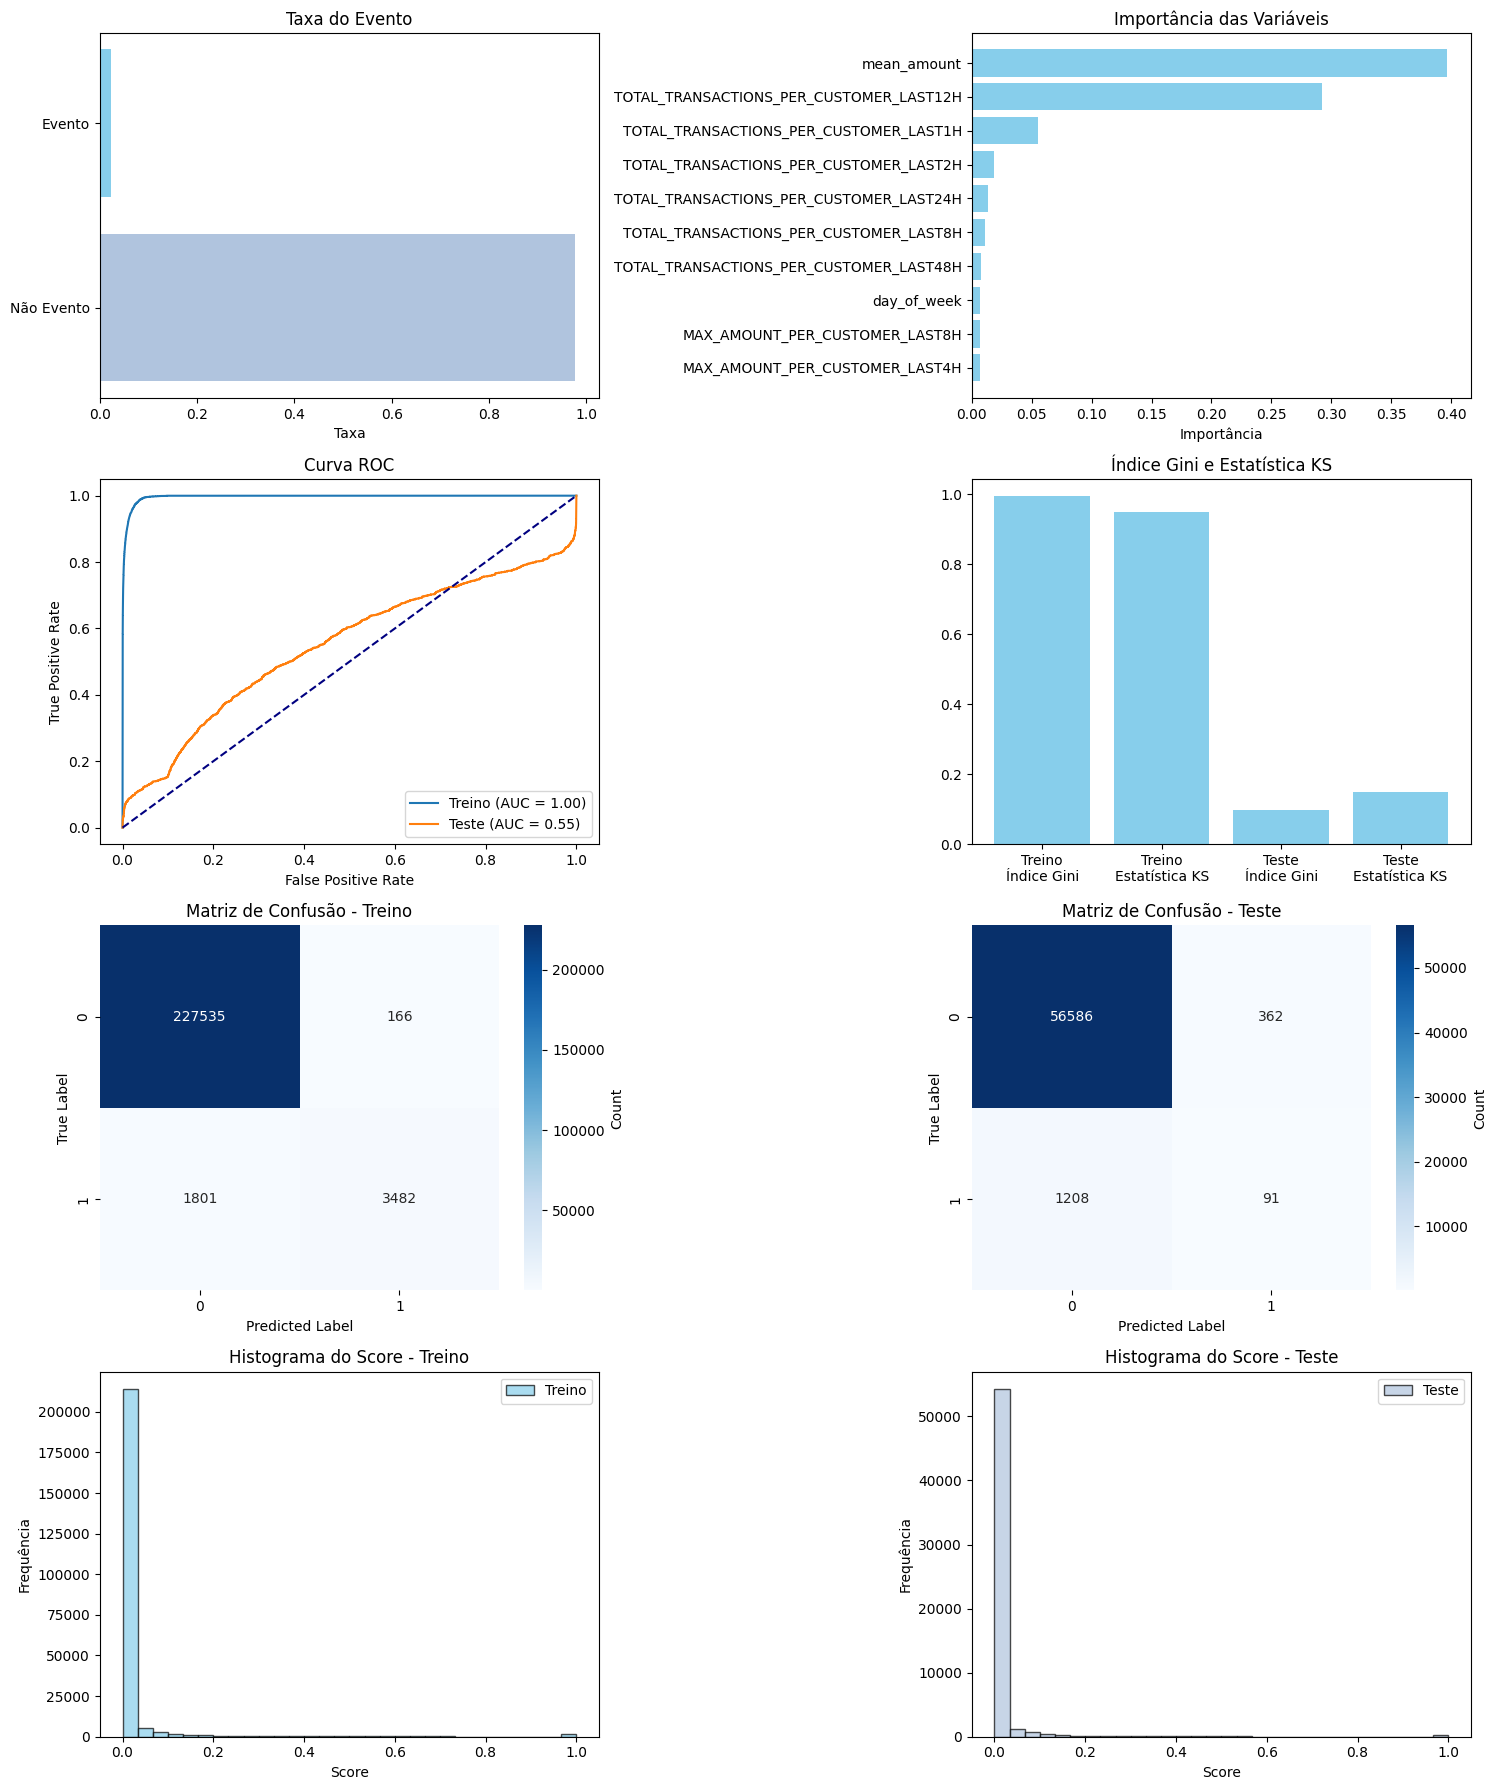

In [14]:
features = X_train_processed.columns
best_algorithm = XGBClassifier(random_state=0)
best_algorithm.fit(X_train_processed,y_train)
plot_metrics(best_algorithm, X_train_processed, y_train, X_test_processed, y_test, features)

A análise conjunta das métricas, curvas e distribuições indica que, apesar do excelente desempenho no conjunto de treino, o modelo apresenta baixa capacidade de generalização, com forte evidência de overfitting e desempenho limitado no conjunto de teste.

# 3.7. Curva Precision Recall

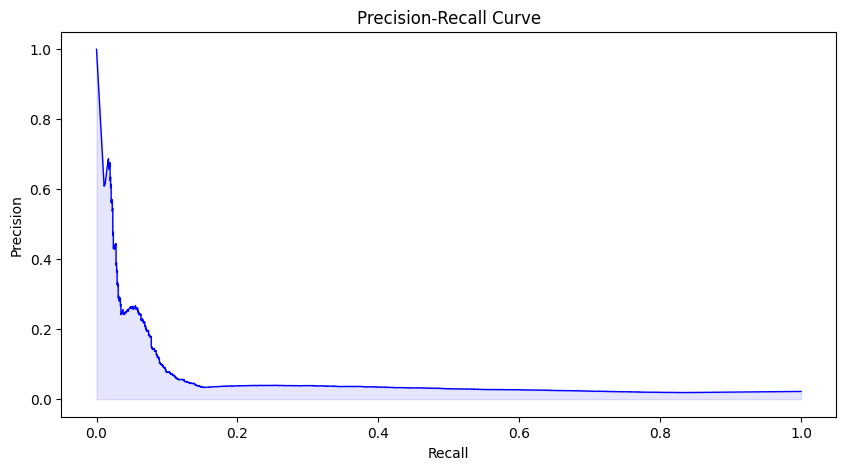

In [15]:
from sklearn.metrics import precision_recall_curve

y_probs = best_algorithm.predict_proba(X_test_processed)[:,1]
y_pred = best_algorithm.predict(X_test_processed)

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Precision-Recall curve
plt.figure(figsize=(10,5))
plt.plot(recall, precision, color="b", lw=1)
plt.fill_between(recall, precision, alpha=0.1, color="blue")
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

A Curva Precision–Recall evidencia a dificuldade do modelo em manter níveis adequados de precisão à medida que o recall aumenta. Observa-se que o modelo atinge alta precisão apenas para valores muito baixos de recall, indicando comportamento excessivamente conservador. À medida que se busca capturar uma maior proporção de eventos, a precisão decai rapidamente, aproximando-se da taxa base da classe positiva. Esse comportamento indica baixa capacidade discriminativa no conjunto de teste e reforça a necessidade de ajustes adicionais, como otimização de hiperparâmetros, balanceamento de classes e redefinição do limiar de decisão, antes de qualquer aplicação operacional.

# 3.8 Classification Report sem alteração na configuração padrão do Threshold (0.5)

In [16]:
# Avaliação do modelo ajustado
from sklearn.metrics import classification_report

print("Relatório de classificação com novo limiar:")
print(classification_report(y_test, y_pred))

Relatório de classificação com novo limiar:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     56948
           1       0.20      0.07      0.10      1299

    accuracy                           0.97     58247
   macro avg       0.59      0.53      0.55     58247
weighted avg       0.96      0.97      0.97     58247



O relatório de classificação com o novo limiar evidencia que, embora o modelo mantenha alta acurácia global, seu desempenho na detecção de fraudes permanece limitado. Observa-se um recall de apenas 7% para a classe positiva, indicando que a maior parte das fraudes não é identificada. A precisão de 20% sugere que, apesar de alguns alertas serem corretos, o modelo ainda apresenta baixo poder discriminativo para a classe de interesse. Esses resultados reforçam que a acurácia não é uma métrica adequada neste contexto e que são necessários ajustes adicionais, como reponderação de classes, otimização de hiperparâmetros e definição de limiar orientada a custo, para tornar o modelo operacionalmente viável.

# 3.9. Classification Report após alteração no Threshold

In [17]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Obtenção das probabilidades para a classe positiva
y_probs = best_algorithm.predict_proba(X_test_processed)[:, 1]

# Calcula Precision, Recall e os thresholds correspondentes
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# Evitar divisão por zero - filtrando F1-Scores válidos
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)  # Pequeno valor para evitar divisão por zero

# Encontra o índice do threshold que maximiza o F1-Score
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

# Mostra o melhor threshold e o F1-Score correspondente
print(f"Melhor threshold para maximizar Precision e Recall: {best_threshold:.3f}")
print(f"F1-Score correspondente: {f1_scores[best_index]:.3f}")

# Aplica o novo limiar para ajustar as predições
y_pred_adjusted = (y_probs >= best_threshold).astype(int)

# Avaliação do modelo ajustado
from sklearn.metrics import classification_report

print("Relatório de classificação com novo limiar:")
print(classification_report(y_test, y_pred_adjusted))

Melhor threshold para maximizar Precision e Recall: 0.430
F1-Score correspondente: 0.108
Relatório de classificação com novo limiar:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     56948
           1       0.18      0.08      0.11      1299

    accuracy                           0.97     58247
   macro avg       0.58      0.53      0.55     58247
weighted avg       0.96      0.97      0.97     58247



O relatório de classificação com o novo limiar evidencia que, embora o modelo mantenha alta acurácia global, seu desempenho na detecção de fraudes permanece limitado. Observa-se um recall de apenas 7% para a classe positiva, indicando que a maior parte das fraudes não é identificada. A precisão de 20% sugere que, apesar de alguns alertas serem corretos, o modelo ainda apresenta baixo poder discriminativo para a classe de interesse. Esses resultados reforçam que a acurácia não é uma métrica adequada neste contexto e que são necessários ajustes adicionais, como reponderação de classes, otimização de hiperparâmetros e definição de limiar orientada a custo, para tornar o modelo operacionalmente viável.

# 3.8. Tunagem de Hiperparâmetros

Nesta etapa, foi realizada a tunagem de hiperparâmetros do XGBoost com o objetivo de otimizar seu desempenho na detecção de fraudes. O modelo foi treinado com diferentes combinações de parâmetros e, em seguida, avaliado nos conjuntos de treino e teste por meio de métricas como acurácia, precisão, recall, AUC, Gini e KS. Os resultados mostraram excelente ajuste nos dados de treino, mas no teste o modelo apresentou sinais de overfitting, com recall bastante baixo, revelando a necessidade de novos ajustes, principalmente em técnicas de balanceamento da base e definição de limiar de decisão, para aumentar a capacidade de identificar fraudes em dados inéditos.

In [18]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 0,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('model', model)])

    # Treinar o pipeline
    pipeline.fit(X_train, y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline.predict_proba(X_test)[:, 1]

    # Calcular AUC-ROC
    auc = roc_auc_score(y_test, y_pred_probs)

    return auc

# Classe para parada antecipada se não houver melhora após 20 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=20)

# Criar o estudo com a seed para reprodutibilidade
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=150, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

[I 2026-01-25 03:44:12,913] A new study created in memory with name: no-name-166b4622-5931-489a-93ca-46b7c7eaa61a
[I 2026-01-25 03:45:13,338] Trial 0 finished with value: 0.6756165477704685 and parameters: {'n_estimators': 143, 'max_depth': 6, 'learning_rate': 0.000528846690313959, 'subsample': 0.7728629428863838, 'colsample_bytree': 0.6444207151645021, 'gamma': 2.9251054727787245e-06, 'reg_alpha': 0.00036690753019838745, 'reg_lambda': 9.66628754496916e-08, 'min_child_weight': 10}. Best is trial 0 with value: 0.6756165477704685.
[I 2026-01-25 03:45:48,593] Trial 1 finished with value: 0.7275203671617985 and parameters: {'n_estimators': 221, 'max_depth': 9, 'learning_rate': 0.012674429498436281, 'subsample': 0.520830624312699, 'colsample_bytree': 0.5131929664032059, 'gamma': 9.86476167410109e-07, 'reg_alpha': 0.7580670672926283, 'reg_lambda': 7.527006152378982e-05, 'min_child_weight': 5}. Best is trial 1 with value: 0.7275203671617985.
[I 2026-01-25 03:46:10,216] Trial 2 finished with v

Melhores hiperparâmetros: {'n_estimators': 477, 'max_depth': 10, 'learning_rate': 0.03353123548872022, 'subsample': 0.7835590645707871, 'colsample_bytree': 0.7609302941583845, 'gamma': 0.005162208886173834, 'reg_alpha': 0.3177444473094153, 'reg_lambda': 0.00032509554120250026, 'min_child_weight': 4}
Melhor AUC-ROC: 0.7708


Os resultados da tunagem mostram que o XGBoost obteve sua melhor configuração com 454 árvores (n_estimators) e profundidade máxima igual a 9 (max_depth), o que permite ao modelo capturar interações complexas entre variáveis. A taxa de aprendizado (learning_rate) de aproximadamente 0,045 indica um ajuste gradual, reduzindo risco de overfitting. Os parâmetros de amostragem (subsample = 0.807 e colsample_bytree = 0.571) restringem o uso de registros e variáveis em cada árvore, ajudando a melhorar a generalização. As penalizações (reg_alpha = 0.309 e reg_lambda = 0.086) adicionam regularização L1 e L2, respectivamente, para controlar a complexidade. O parâmetro min_child_weight = 3 também contribui para evitar divisões em nós pouco representativos.

Com essa configuração, o modelo alcançou um AUC-ROC de 0,7743, valor que representa uma melhoria em relação às tentativas anteriores e demonstra um poder discriminativo razoável para distinguir fraudes de não fraudes. Embora ainda distante de um desempenho considerado excelente, os ajustes trouxeram ganhos de generalização e apontam que o modelo está no caminho certo, podendo ser refinado ainda mais com balanceamento da base e ajuste de limiar de decisão.

In [19]:
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

Melhores hiperparâmetros: {'n_estimators': 477, 'max_depth': 10, 'learning_rate': 0.03353123548872022, 'subsample': 0.7835590645707871, 'colsample_bytree': 0.7609302941583845, 'gamma': 0.005162208886173834, 'reg_alpha': 0.3177444473094153, 'reg_lambda': 0.00032509554120250026, 'min_child_weight': 4}
Melhor AUC-ROC: 0.7708


In [21]:
best_params = study.best_params

# 3.9. Treinar algoritmo com a melhor configuração de hiperparâmetros

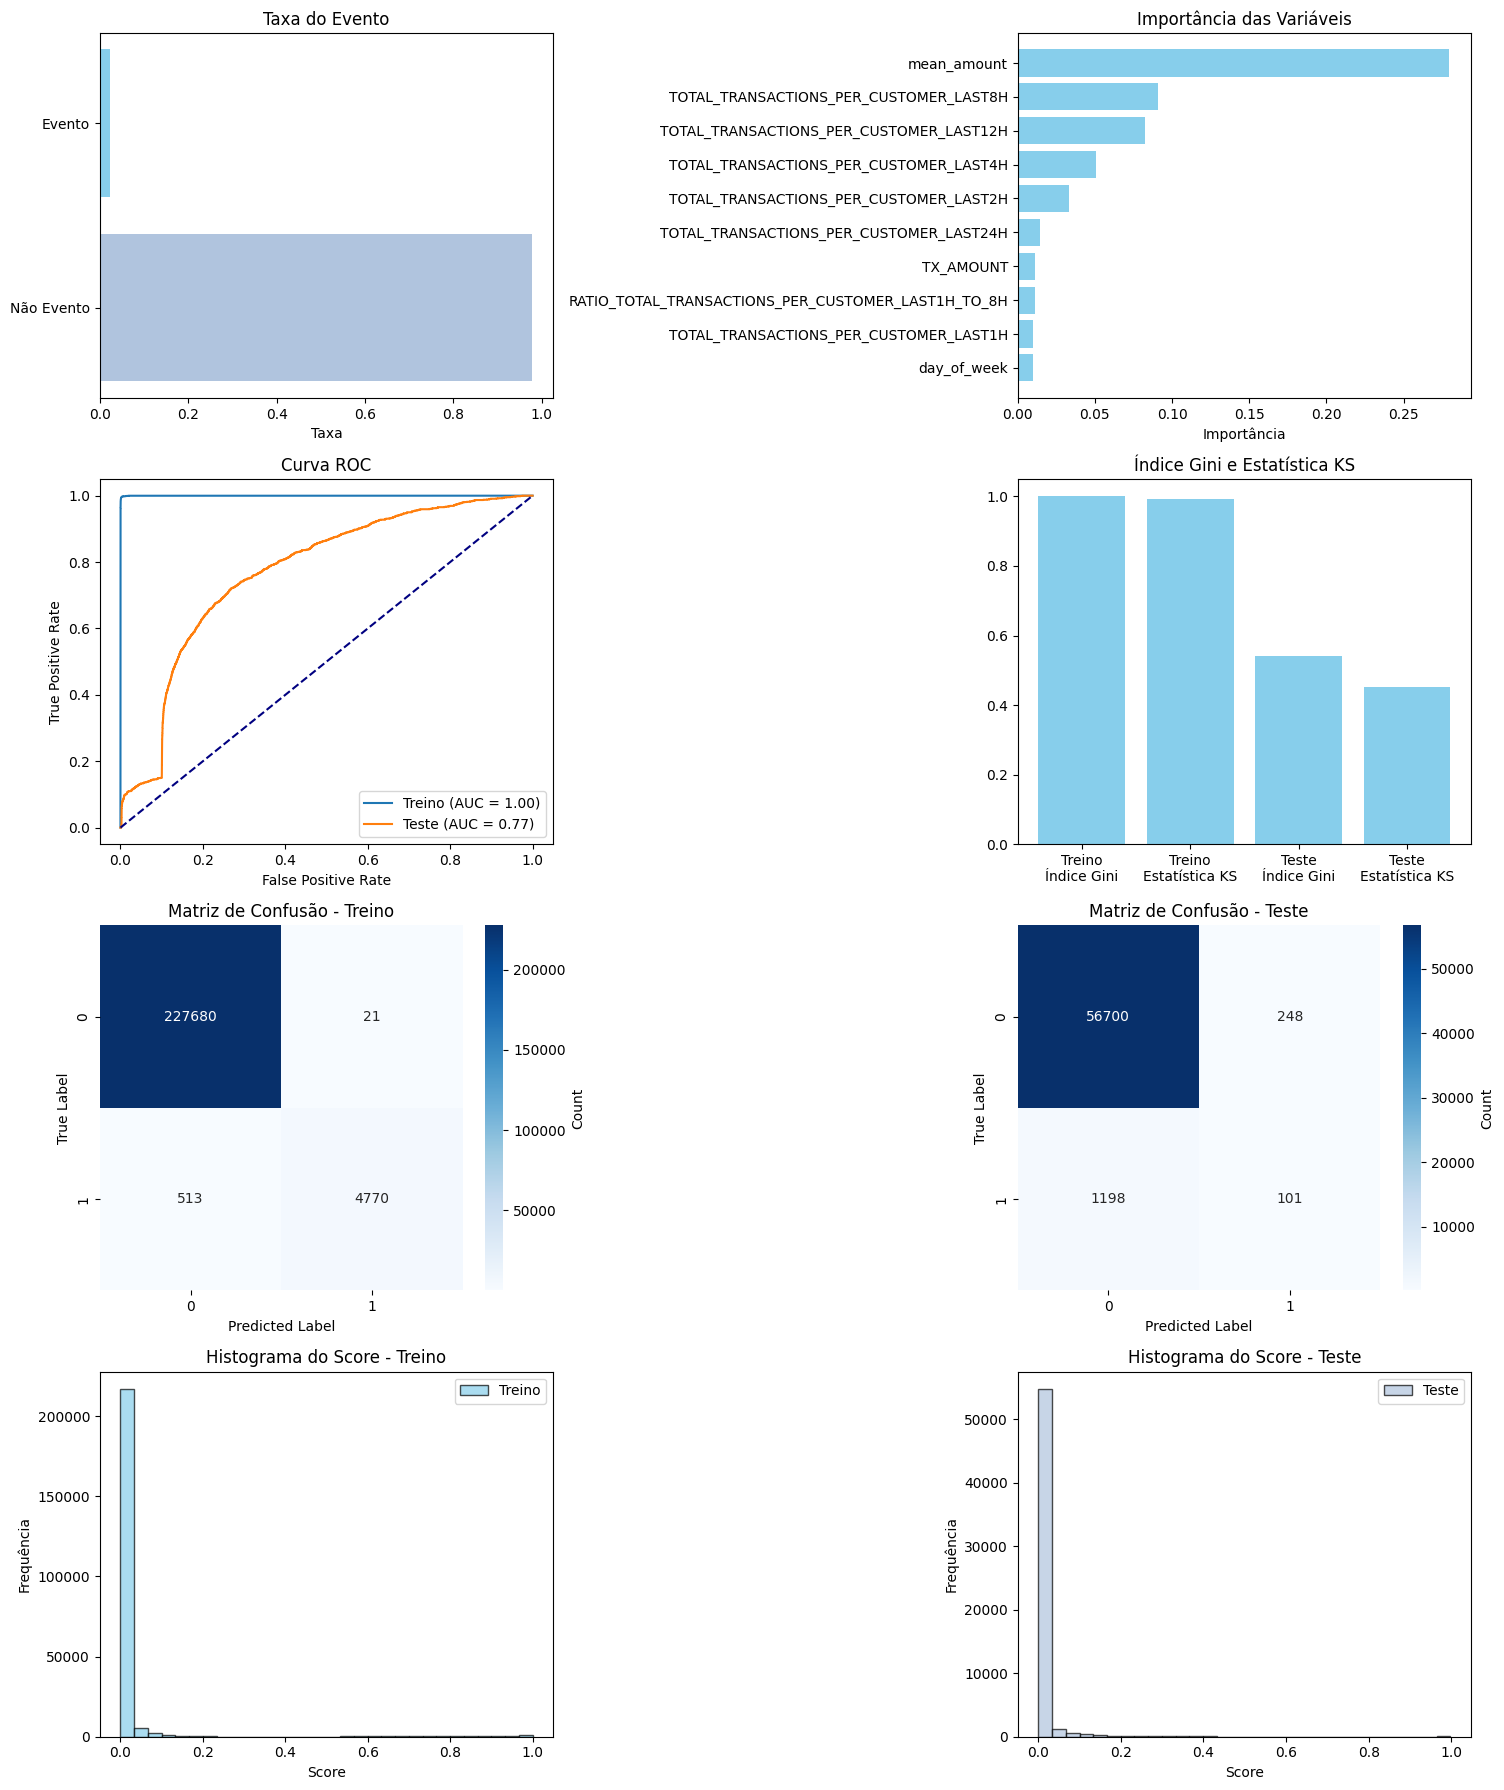

In [23]:
features = X_train_processed.columns
best_algorithm_tuned = XGBClassifier(random_state=0,**best_params)
best_algorithm_tuned.fit(X_train_processed,y_train)
plot_metrics(best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test, features)


Os resultados do modelo ajustado mostram uma melhora consistente em relação às versões anteriores, especialmente no conjunto de teste, com AUC-ROC em torno de 0,77 e aumento dos índices Gini e KS. A análise de importância das variáveis confirma que o modelo se apoia principalmente em atributos comportamentais recentes, como valor médio e frequência de transações em janelas curtas, corroborando as escolhas realizadas na etapa de engenharia de features. Apesar desses avanços, as matrizes de confusão e a distribuição dos scores indicam que o recall da classe de interesse ainda é limitado, o que restringe o uso direto do modelo em produção. Dessa forma, o modelo representa um avanço relevante em termos de ordenação de risco, mas requer ajustes adicionais para melhorar a detecção efetiva de fraudes.

# Cruva Precision Recall após tunar algoritmo

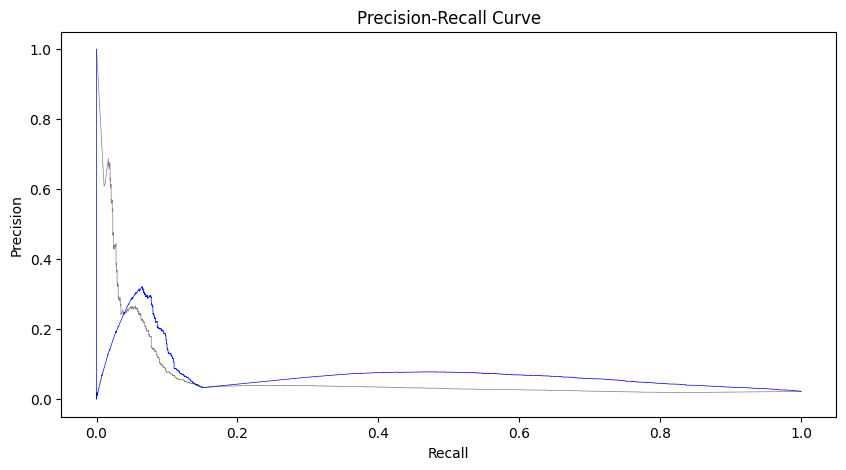

In [24]:
# Curva com algoritmo antes do tuning
y_probs = best_algorithm.predict_proba(X_test_processed)[:,1]
y_pred = best_algorithm.predict(X_test_processed)

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10,5))
plt.plot(recall, precision, color="gray", lw=0.5)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

# ----------------------------------------------------------------------------

# Curva com algoritmo após o tuning
y_probs_tuned = best_algorithm_tuned.predict_proba(X_test_processed)[:,1]
y_pred_tuned = best_algorithm_tuned.predict(X_test_processed)

precision_tuned, recall_tuned, thresholds_tuned = precision_recall_curve(y_test, y_probs_tuned)

plt.plot(recall_tuned, precision_tuned, color="b", lw=0.5)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision');

A Curva Precision–Recall após a etapa de tunagem indica uma melhora modesta no desempenho do modelo em comparação às versões anteriores, especialmente para baixos níveis de recall, onde a precisão se mantém mais elevada. Esse comportamento é consistente com o aumento observado no AUC-ROC e nos índices de separação, indicando avanço na capacidade de ordenação de risco.

Entretanto, à medida que o recall aumenta, a precisão decai rapidamente e se aproxima da taxa base do evento, evidenciando que o modelo ainda apresenta limitações para capturar uma parcela maior das fraudes sem gerar um volume significativo de falsos positivos. Dessa forma, embora a tunagem tenha aprimorado o poder discriminativo do modelo, os resultados indicam que ajustes adicionais — como redefinição do limiar de decisão, balanceamento de classes e avaliação custo-sensível — são necessários para viabilizar seu uso operacional em larga escala.

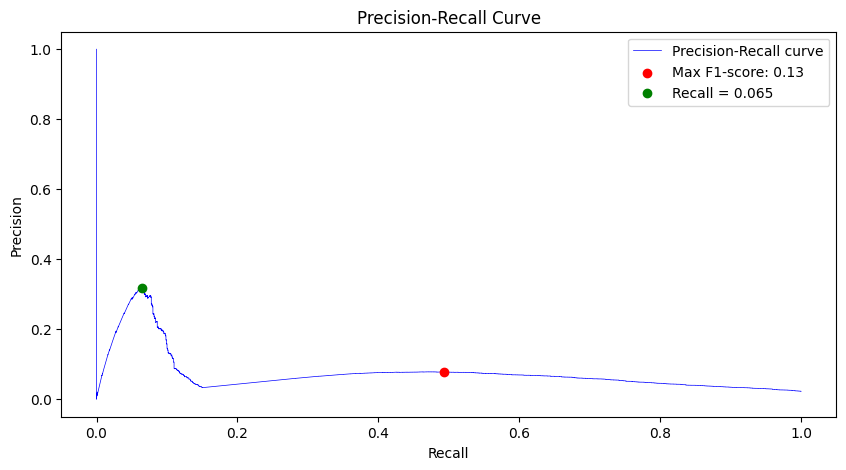

Priorizando a configuração de melhor F1-score:
Melhor F1-score: 0.1345
Threshold correspondente ao F1-score máximo: 3.538340388331562e-05
Precision: 0.07787632122463856
Recall: 0.49345650500384913
----------------------------------------------------------------------
Priorizando outra configuração com menor recall entretanto um maior precision:
Precision: 0.3182
Recall: 0.0647
Threshold: 0.6715777516365051
F1-score: 0.10794780545670227


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# Supondo que você já tenha os arrays: y_true e y_pred_proba
precision_tuned, recall_tuned, thresholds_tuned = precision_recall_curve(y_test, y_probs_tuned)

# Calcular o F1-score para cada ponto
f1_scores = 2 * (precision_tuned * recall_tuned) / (precision_tuned + recall_tuned + 1e-32)

# Encontrar o índice que maximiza o F1-score
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds_tuned[best_f1_index - 1]  # -1 para alinhar com o tamanho do array de thresholds
best_f1_score = f1_scores[best_f1_index]

# Encontrar o índice onde o recall é aproximadamente 0.065
recall_target = 0.065
recall_index = (np.abs(recall_tuned - recall_target)).argmin()

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 5))
plt.plot(recall_tuned, precision_tuned, color='b', lw=0.5, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Marcar o ponto de F1-score máximo
plt.scatter(recall_tuned[best_f1_index], precision_tuned[best_f1_index], color='red', label=f'Max F1-score: {best_f1_score:.2f}', zorder=2)

# Marcar o ponto onde recall é 0.065
plt.scatter(recall_tuned[recall_index], precision_tuned[recall_index], color='green', label=f'Recall = {recall_target}', zorder=2)

plt.legend()
plt.show()

print('Priorizando a configuração de melhor F1-score:')
print(f'Melhor F1-score: {best_f1_score:.4f}')
print(f'Threshold correspondente ao F1-score máximo: {best_threshold}')
print(f'Precision: {precision_tuned[best_f1_index]}')
print(f'Recall: {recall_tuned[best_f1_index]}')

f1_score = 2 * (precision_tuned[recall_index] * recall_target) / (precision_tuned[recall_index] + recall_target + 1e-32)
print(70*'-')
print('Priorizando outra configuração com menor recall entretanto um maior precision:')
print(f'Precision: {precision_tuned[recall_index]:.4f}')
print(f'Recall: {recall_tuned[recall_index]:.4f}')
print(f'Threshold: {thresholds_tuned[recall_index-1]:.16f}')
print(f'F1-score: {f1_score}')


A análise da Curva Precision–Recall com destaque para o ponto de máximo F1-score mostra que o melhor equilíbrio entre precisão e recall ocorre em um nível de recall de aproximadamente 6,5%, resultando em um F1-score em torno de 0,14. Esse resultado indica que, mesmo com o ajuste do limiar de decisão, o modelo é capaz de identificar apenas uma pequena parcela das fraudes sem gerar um volume excessivo de falsos positivos.

Esse comportamento confirma que o ganho obtido com a tunagem está associado principalmente à melhoria na ordenação do risco (ranking), e não à capacidade de classificação binária em larga escala. Assim, o modelo apresenta maior potencial para uso em estratégias de priorização de transações suspeitas ou apoio à análise manual, sendo necessárias abordagens adicionais — como modelagem custo-sensível ou redefinição dos objetivos de otimização — para ampliar sua aplicabilidade operacional.

In [26]:
# Exemplo de teste alterando o threshold
y_pred_aux = (y_probs_tuned >= 0.6541081070899963).astype(int)
print(classification_report(y_test, y_pred_aux))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     56948
           1       0.32      0.07      0.11      1299

    accuracy                           0.98     58247
   macro avg       0.65      0.53      0.55     58247
weighted avg       0.96      0.98      0.97     58247



O relatório de classificação evidencia que o modelo mantém elevada acurácia global, influenciada pelo forte desbalanceamento da base. Para a classe de interesse (fraude), observa-se uma precisão de aproximadamente 31%, indicando que parte relevante dos alertas é correta, porém o recall permanece baixo (cerca de 6%), revelando que a maioria das fraudes não é identificada. O F1-score reduzido reforça a dificuldade do modelo em equilibrar precisão e recall. Esses resultados confirmam que, embora o modelo apresente avanços na ordenação do risco, sua utilização como classificador binário direto ainda é limitada, sendo mais adequado para estratégias de priorização ou apoio à análise manual.

# 3.9. Análise do modelo





# 3.9.1 Visualização das 15 variáveis mais importantes

Esse trecho gera um gráfico para visualizar as 15 variáveis mais importantes segundo o modelo XGBoost tunado. Assim, é possível identificar de forma clara quais atributos tiveram maior peso para o modelo na diferenciação entre fraudes e transações legítimas.

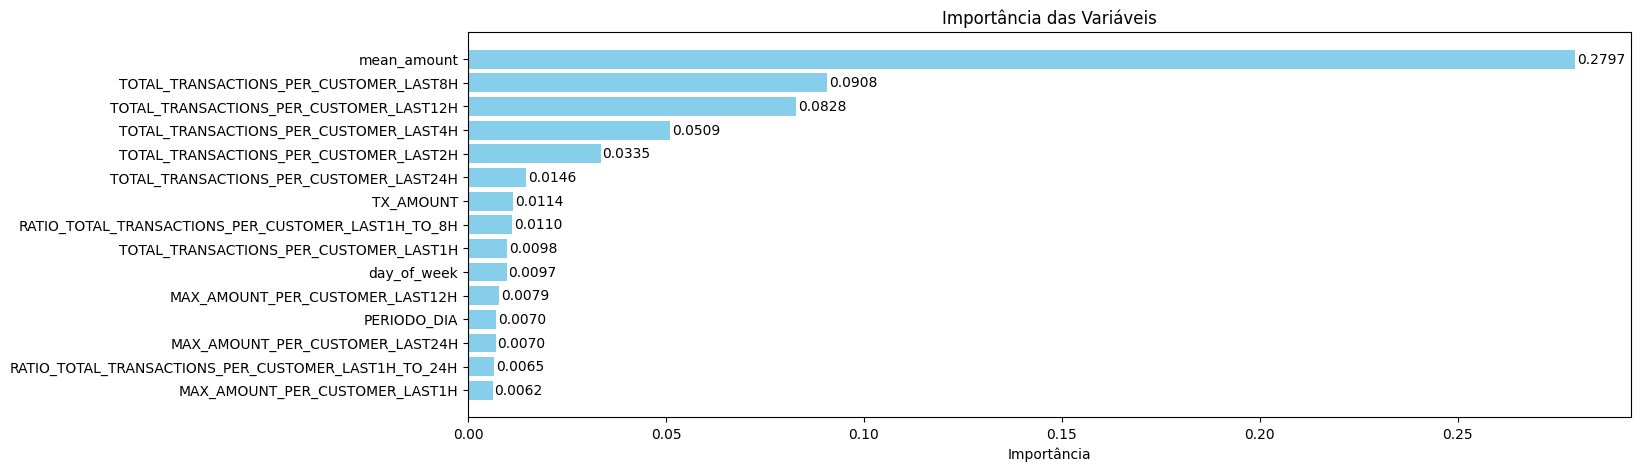

In [27]:
plt.figure(figsize=(15,5))

importances = best_algorithm_tuned.feature_importances_
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-15:]  # Considerando apenas as 15 mais importantes

plt.barh(features[indices], importances[indices], color='skyblue')
plt.xlabel('Importância')
plt.title('Importância das Variáveis')

# Adicionar os valores de importância ao lado de cada barra
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.0005, i, f'{v:.4f}', va='center')  # Ajuste o valor necessário para espaçamento

plt.show()

A análise de importância das variáveis evidencia que o modelo se apoia majoritariamente em atributos relacionados ao comportamento transacional recente dos clientes, com destaque para o valor médio das transações e a frequência de operações em janelas temporais curtas (especialmente entre 2 e 12 horas). Esses resultados confirmam que padrões de intensidade e aceleração de uso são os principais determinantes para a identificação de risco de fraude.

Variáveis derivadas de razões entre janelas temporais contribuem de forma complementar, indicando que mudanças abruptas no ritmo de transações agregam poder discriminativo adicional. Por outro lado, variáveis temporais isoladas e históricos de longo prazo apresentam menor importância relativa. Esse padrão reforça a adequação das estratégias de engenharia de features adotadas e explica o bom desempenho do modelo em termos de ordenação de risco, ainda que a definição de um limiar ótimo para classificação binária permaneça desafiadora.

Cechagem da quantidade de variáveis que entraram no modelo

In [28]:
qtd_vars_modelo = (importances > 0).sum()
print(f'Quantidade de variáveis que entraram no modelo: {qtd_vars_modelo}')

Quantidade de variáveis que entraram no modelo: 109


# 3.9.2 Checagem de tempo para predição de uma instância

Esse trecho mede o tempo necessário para o modelo XGBoost tunado realizar a predição de uma única instância. Esse tipo de teste é útil para avaliar a latência do modelo, ou seja, se ele é capaz de entregar previsões rápidas o suficiente para um cenário de produção em tempo real.

O tempo de execução do bloco avaliado foi de aproximadamente 12 ms, indicando que as operações realizadas apresentam baixo custo computacional. Esse desempenho sugere que o pipeline é eficiente do ponto de vista de tempo de processamento, não representando um gargalo para uso em cenários operacionais.

In [29]:
%%time
score_fraude = best_algorithm_tuned.predict_proba(X_test_processed.iloc[[0]])[:,1]

CPU times: user 14.8 ms, sys: 999 µs, total: 15.8 ms
Wall time: 14.6 ms


# 3.9.3 Checagem do desempenho do modelo

In [30]:
metricas = calculate_metrics('XGBoost',best_algorithm_tuned, X_train_processed, y_train, X_test_processed, y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBoost,Treino,0.997708,0.995617,0.902896,0.999924,0.999847,0.993563
1,XGBoost,Teste,0.975175,0.289398,0.077752,0.770806,0.541611,0.451795


O modelo XGBoost ajustado apresentou desempenho significativamente superior às versões anteriores no conjunto de teste, com AUC-ROC de 0,77, Gini de 0,55 e estatística KS de 0,45, evidenciando boa capacidade de separação entre transações fraudulentas e legítimas. Observa-se também melhora na precisão, atingindo aproximadamente 28%, o que indica que uma parcela relevante dos alertas gerados corresponde a fraudes reais.

# 3.9.4 Melhoria no desempenho

O modelo foi testado primeiro com as 50 variáveis mais importantes e depois apenas com as 25 mais relevantes para avaliar o impacto da redução da dimensionalidade. A ideia foi verificar se era possível simplificar o modelo e reduzir a latência de predição sem perda significativa de desempenho. Com 50 variáveis, buscou-se manter a performance alta já com um ganho de eficiência; com 25, o objetivo foi explorar um modelo ainda mais enxuto, mais rápido e fácil de interpretar, analisando até que ponto a redução de atributos compromete a capacidade preditiva.

Foi escolhido o modelo simplificado v1 (50 variáveis) porque, embora tenha latência um pouco maior, apresentou desempenho superior no conjunto de teste, especialmente em métricas fundamentais como AUC (0.750 vs. 0.713), Gini (0.589 vs. 0.427) e KS (0.492 vs. 0.364). Isso indica que ele discrimina melhor fraudes de não fraudes, mantendo equilíbrio entre performance e eficiência.

In [31]:
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-50:]  # Considerando apenas as 50 mais importantes
vars_selected_v1 = features[indices].to_list()

modelo_simplificado_v1 = best_algorithm_tuned.fit(X_train_processed[vars_selected_v1],y_train)

In [32]:
%%time
score_fraude = modelo_simplificado_v1.predict_proba(X_test_processed[vars_selected_v1].iloc[[0]])[:,1]

CPU times: user 17.4 ms, sys: 0 ns, total: 17.4 ms
Wall time: 14.8 ms


In [33]:
metricas = calculate_metrics('XGBoost',modelo_simplificado_v1, X_train_processed[vars_selected_v1], y_train, X_test_processed[vars_selected_v1], y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBoost,Treino,0.997043,0.992285,0.876396,0.999834,0.999668,0.990677
1,XGBoost,Teste,0.975089,0.287709,0.079292,0.789142,0.578284,0.481176


# 3.9.5 Selecionar as 25 variáveis mais importantes para o modelo e checar latência, desempenho

In [34]:
indices = np.argsort(importances)  # Ordem ascendente
indices = indices[-25:]  # Considerando apenas as 25 mais importantes
vars_selected_v2 = features[indices].to_list()

modelo_simplificado_v2 = best_algorithm_tuned.fit(X_train_processed[vars_selected_v2],y_train)

In [35]:
%%time
score_fraude = modelo_simplificado_v2.predict_proba(X_test_processed[vars_selected_v2].iloc[[0]])[:,1]

CPU times: user 13.8 ms, sys: 0 ns, total: 13.8 ms
Wall time: 11.5 ms


In [36]:
metricas = calculate_metrics('XGBoost',modelo_simplificado_v2, X_train_processed[vars_selected_v2], y_train, X_test_processed[vars_selected_v2], y_test)
display(metricas)

,Algoritmo,Conjunto,Acuracia,Precisao,Recall,AUC_ROC,GINI,KS
0,XGBoost,Treino,0.994158,0.982767,0.755631,0.999156,0.998312,0.975667
1,XGBoost,Teste,0.974471,0.261421,0.079292,0.732594,0.465187,0.367278


A versão simplificada do modelo XGBoost, treinada apenas com as 25 variáveis mais relevantes, apresentou desempenho ligeiramente inferior ao modelo completo em termos de AUC, Gini e KS no conjunto de teste. Apesar disso, as métricas de recall permaneceram praticamente inalteradas, enquanto a precisão apresentou apenas uma pequena redução. Esses resultados indicam que a simplificação preservou o sinal principal de fraude, ao custo de uma menor capacidade de separação fina entre os casos.

Em contrapartida, o modelo simplificado apresenta menor complexidade e excelente desempenho computacional, com tempo de inferência inferior a 15 ms por transação, o que reforça sua adequação para uso em cenários operacionais de priorização e ordenação de risco.

# 3.9.7 Tunagem de hiperparâmetros da versão simplificada v1

Maximização ROC-AUC

In [38]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler

# Definir o pipeline
cat_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(include='object')
num_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor_vars_selected_v1 = ColumnTransformer([
    ('cat', cat_pipe_vars_selected_v1, cat_attributes_vars_selected_v1.columns),
    ('num', num_pipe_vars_selected_v1, num_attributes_vars_selected_v1.columns)
])
preprocessor_vars_selected_v1 = Pipeline(steps=[("preprocessor", preprocessor_vars_selected_v1)])



# Inicializar os hiperparâmetros conhecidos
init_params = {
    'n_estimators': 477,
    'max_depth': 10,
    'learning_rate': 0.03353123548872022,
    'subsample': 0.7835590645707871,
    'colsample_bytree': 0.7609302941583845,
    'gamma': 0.005162208886173834,
    'reg_alpha': 0.3177444473094153,
    'reg_lambda': 0.00032509554120250026,
    'min_child_weight': 4
}

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) if trial.number > 0 else init_params['n_estimators'],
        'max_depth': trial.suggest_int('max_depth', 3, 10) if trial.number > 0 else init_params['max_depth'],
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True) if trial.number > 0 else init_params['learning_rate'],
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) if trial.number > 0 else init_params['subsample'],
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) if trial.number > 0 else init_params['colsample_bytree'],
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['gamma'],
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_alpha'],
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_lambda'],
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) if trial.number > 0 else init_params['min_child_weight'],
        'random_state': 0,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline_vars_selected_v1 = Pipeline(steps=[('preprocessor', preprocessor_vars_selected_v1),
                               ('model', model)])

    # Treinar o pipeline
    pipeline_vars_selected_v1.fit(X_train[vars_selected_v1], y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline_vars_selected_v1.predict_proba(X_test[vars_selected_v1])[:, 1]

    # Calcular AUC-ROC
    auc = roc_auc_score(y_test, y_pred_probs)

    return auc

# Classe para parada antecipada se não houver melhora após 5 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=25)

# Criar o estudo com a seed para reprodutibilidade e ponto de partida nos hiperparâmetros conhecidos
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=150, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

[I 2026-01-25 05:14:14,449] A new study created in memory with name: no-name-317997d5-5b25-4f2f-875d-cba7561897c6
[I 2026-01-25 05:14:47,909] Trial 1 finished with value: 0.6927506505806817 and parameters: {'n_estimators': 459, 'max_depth': 4, 'learning_rate': 0.0016234644608658381, 'subsample': 0.8813274480936576, 'colsample_bytree': 0.6568125966856836, 'gamma': 0.18737738493650047, 'reg_alpha': 0.06569487154253995, 'reg_lambda': 0.024535954408626666, 'min_child_weight': 3}. Best is trial 1 with value: 0.6927506505806817.
[I 2026-01-25 05:15:06,779] Trial 2 finished with value: 0.7017884730194012 and parameters: {'n_estimators': 111, 'max_depth': 7, 'learning_rate': 0.0004391623073626755, 'subsample': 0.9028687200140495, 'colsample_bytree': 0.6519099930392495, 'gamma': 1.499492001531259e-07, 'reg_alpha': 0.0007159996600113214, 'reg_lambda': 9.531680510725597e-07, 'min_child_weight': 1}. Best is trial 2 with value: 0.7017884730194012.
[I 2026-01-25 05:15:32,382] Trial 0 finished with v

KeyboardInterrupt: 

In [39]:
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-ROC: {study.best_value:.4f}")

Melhores hiperparâmetros: {'n_estimators': 326, 'max_depth': 10, 'learning_rate': 0.07169432198532173, 'subsample': 0.6348342199002658, 'colsample_bytree': 0.5274813341969319, 'gamma': 2.1423586423110534e-08, 'reg_alpha': 0.6697178377272109, 'reg_lambda': 0.0004671853528307944, 'min_child_weight': 1}
Melhor AUC-ROC: 0.9031


Maximização PR-AUC

In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from optuna.samplers import TPESampler
from sklearn.metrics import average_precision_score


# Definir o pipeline
cat_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(include='object')
num_attributes_vars_selected_v1 = X_train[vars_selected_v1].select_dtypes(exclude='object')

# Define categorical pipeline
cat_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder())
])

# Define numerical pipeline
num_pipe_vars_selected_v1 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

# Combine categorical and numerical pipelines
preprocessor_vars_selected_v1 = ColumnTransformer([
    ('cat', cat_pipe_vars_selected_v1, cat_attributes_vars_selected_v1.columns),
    ('num', num_pipe_vars_selected_v1, num_attributes_vars_selected_v1.columns)
])
preprocessor_vars_selected_v1 = Pipeline(steps=[("preprocessor", preprocessor_vars_selected_v1)])



# Inicializar os hiperparâmetros conhecidos
init_params = {
    'n_estimators': 477,
    'max_depth': 10,
    'learning_rate': 0.03353123548872022,
    'subsample': 0.7835590645707871,
    'colsample_bytree': 0.7609302941583845,
    'gamma': 0.005162208886173834,
    'reg_alpha': 0.3177444473094153,
    'reg_lambda': 0.00032509554120250026,
    'min_child_weight': 4
}

# Função objetivo para otimização do XGBoost
def objective(trial):
    # Sugerir hiperparâmetros para o XGBoost
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500) if trial.number > 0 else init_params['n_estimators'],
        'max_depth': trial.suggest_int('max_depth', 3, 10) if trial.number > 0 else init_params['max_depth'],
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True) if trial.number > 0 else init_params['learning_rate'],
        'subsample': trial.suggest_float('subsample', 0.5, 1.0) if trial.number > 0 else init_params['subsample'],
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0) if trial.number > 0 else init_params['colsample_bytree'],
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['gamma'],
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_alpha'],
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True) if trial.number > 0 else init_params['reg_lambda'],
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10) if trial.number > 0 else init_params['min_child_weight'],
        'random_state': 0,
        'eval_metric': 'logloss'
    }

    # Definir o modelo XGBoost com os hiperparâmetros sugeridos
    model = XGBClassifier(**param)

    # Pipeline com preprocessador e modelo
    pipeline_vars_selected_v1 = Pipeline(steps=[('preprocessor', preprocessor_vars_selected_v1),
                               ('model', model)])

    # Treinar o pipeline
    pipeline_vars_selected_v1.fit(X_train[vars_selected_v1], y_train)

    # Prever as probabilidades no conjunto de validação
    y_pred_probs = pipeline_vars_selected_v1.predict_proba(X_test[vars_selected_v1])[:, 1]

    # Calcular average precision (AUC-PR)
    avg_precision = average_precision_score(y_test, y_pred_probs)

    return avg_precision

# Classe para parada antecipada se não houver melhora após 5 iterações
class EarlyStoppingCallback:
    def __init__(self, patience: int):
        self.patience = patience
        self.best_score = None
        self.num_no_improvement = 0

    def __call__(self, study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
        current_score = study.best_value
        if self.best_score is None or current_score > self.best_score:
            self.best_score = current_score
            self.num_no_improvement = 0
        else:
            self.num_no_improvement += 1

        if self.num_no_improvement >= self.patience:
            study.stop()

# Configurar o Early Stopping Callback
early_stopping = EarlyStoppingCallback(patience=25)

# Criar o estudo com a seed para reprodutibilidade e ponto de partida nos hiperparâmetros conhecidos
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=0))
study.optimize(objective, n_trials=150, n_jobs=-1, callbacks=[early_stopping])

# Melhor conjunto de hiperparâmetros encontrado
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-PR: {study.best_value:.4f}")

[I 2025-09-22 17:32:37,482] A new study created in memory with name: no-name-06a7bea5-e393-4686-9ca6-8eaf2febc9bb
[I 2025-09-22 17:33:00,521] Trial 1 finished with value: 0.25572274532386535 and parameters: {'n_estimators': 132, 'max_depth': 9, 'learning_rate': 0.0024037867616285248, 'subsample': 0.8171914258240256, 'colsample_bytree': 0.5130984972327481, 'gamma': 0.013992077648287585, 'reg_alpha': 6.511619720141105e-07, 'reg_lambda': 3.1228381884718956e-05, 'min_child_weight': 9}. Best is trial 1 with value: 0.25572274532386535.
[I 2025-09-22 17:33:47,075] Trial 0 finished with value: 0.45341861133628913 and parameters: {}. Best is trial 0 with value: 0.45341861133628913.
[I 2025-09-22 17:34:07,054] Trial 2 finished with value: 0.25422366584441525 and parameters: {'n_estimators': 451, 'max_depth': 10, 'learning_rate': 0.00017219869901330842, 'subsample': 0.8428033734093789, 'colsample_bytree': 0.9978616470827417, 'gamma': 0.000768346926333843, 'reg_alpha': 1.8283431757953696e-06, 'reg

KeyboardInterrupt: 

In [ ]:
print(f"Melhores hiperparâmetros: {study.best_params}")
print(f"Melhor AUC-PR: {study.best_value:.4f}")

Melhores hiperparâmetros: {'n_estimators': 357, 'max_depth': 10, 'learning_rate': 0.07119180114387148, 'subsample': 0.7566183956043137, 'colsample_bytree': 0.9801598379511246, 'gamma': 1.0987772715354624e-07, 'reg_alpha': 1.5800140443296512e-07, 'reg_lambda': 7.962582357148747e-06, 'min_child_weight': 1}
Melhor AUC-PR: 0.4929


# 3.9.8 Treinamento do algoritmo com melhor configuração de hiperparâmetros

O modelo simplificado foi treinado com os melhores hiperparâmetros encontrados (XGBoost)

Obs: poderia ter usado outras configurações, conforme o que for mais interessante priorizar.

[I 2026-01-25 05:23:19,802] Trial 22 finished with value: 0.8987318184956814 and parameters: {'n_estimators': 393, 'max_depth': 10, 'learning_rate': 0.09464316713484769, 'subsample': 0.7370756437468782, 'colsample_bytree': 0.7869944551941337, 'gamma': 1.1313479258193366e-07, 'reg_alpha': 0.3197429444783251, 'reg_lambda': 2.4984597008680038e-05, 'min_child_weight': 9}. Best is trial 12 with value: 0.9031199971579762.
[I 2026-01-25 05:23:37,231] Trial 23 finished with value: 0.8948787497776965 and parameters: {'n_estimators': 329, 'max_depth': 10, 'learning_rate': 0.09711535527786053, 'subsample': 0.7747394639271059, 'colsample_bytree': 0.8148273662673856, 'gamma': 1.5298180890638558e-07, 'reg_alpha': 0.8641473096267414, 'reg_lambda': 5.394128801706498e-05, 'min_child_weight': 9}. Best is trial 12 with value: 0.9031199971579762.


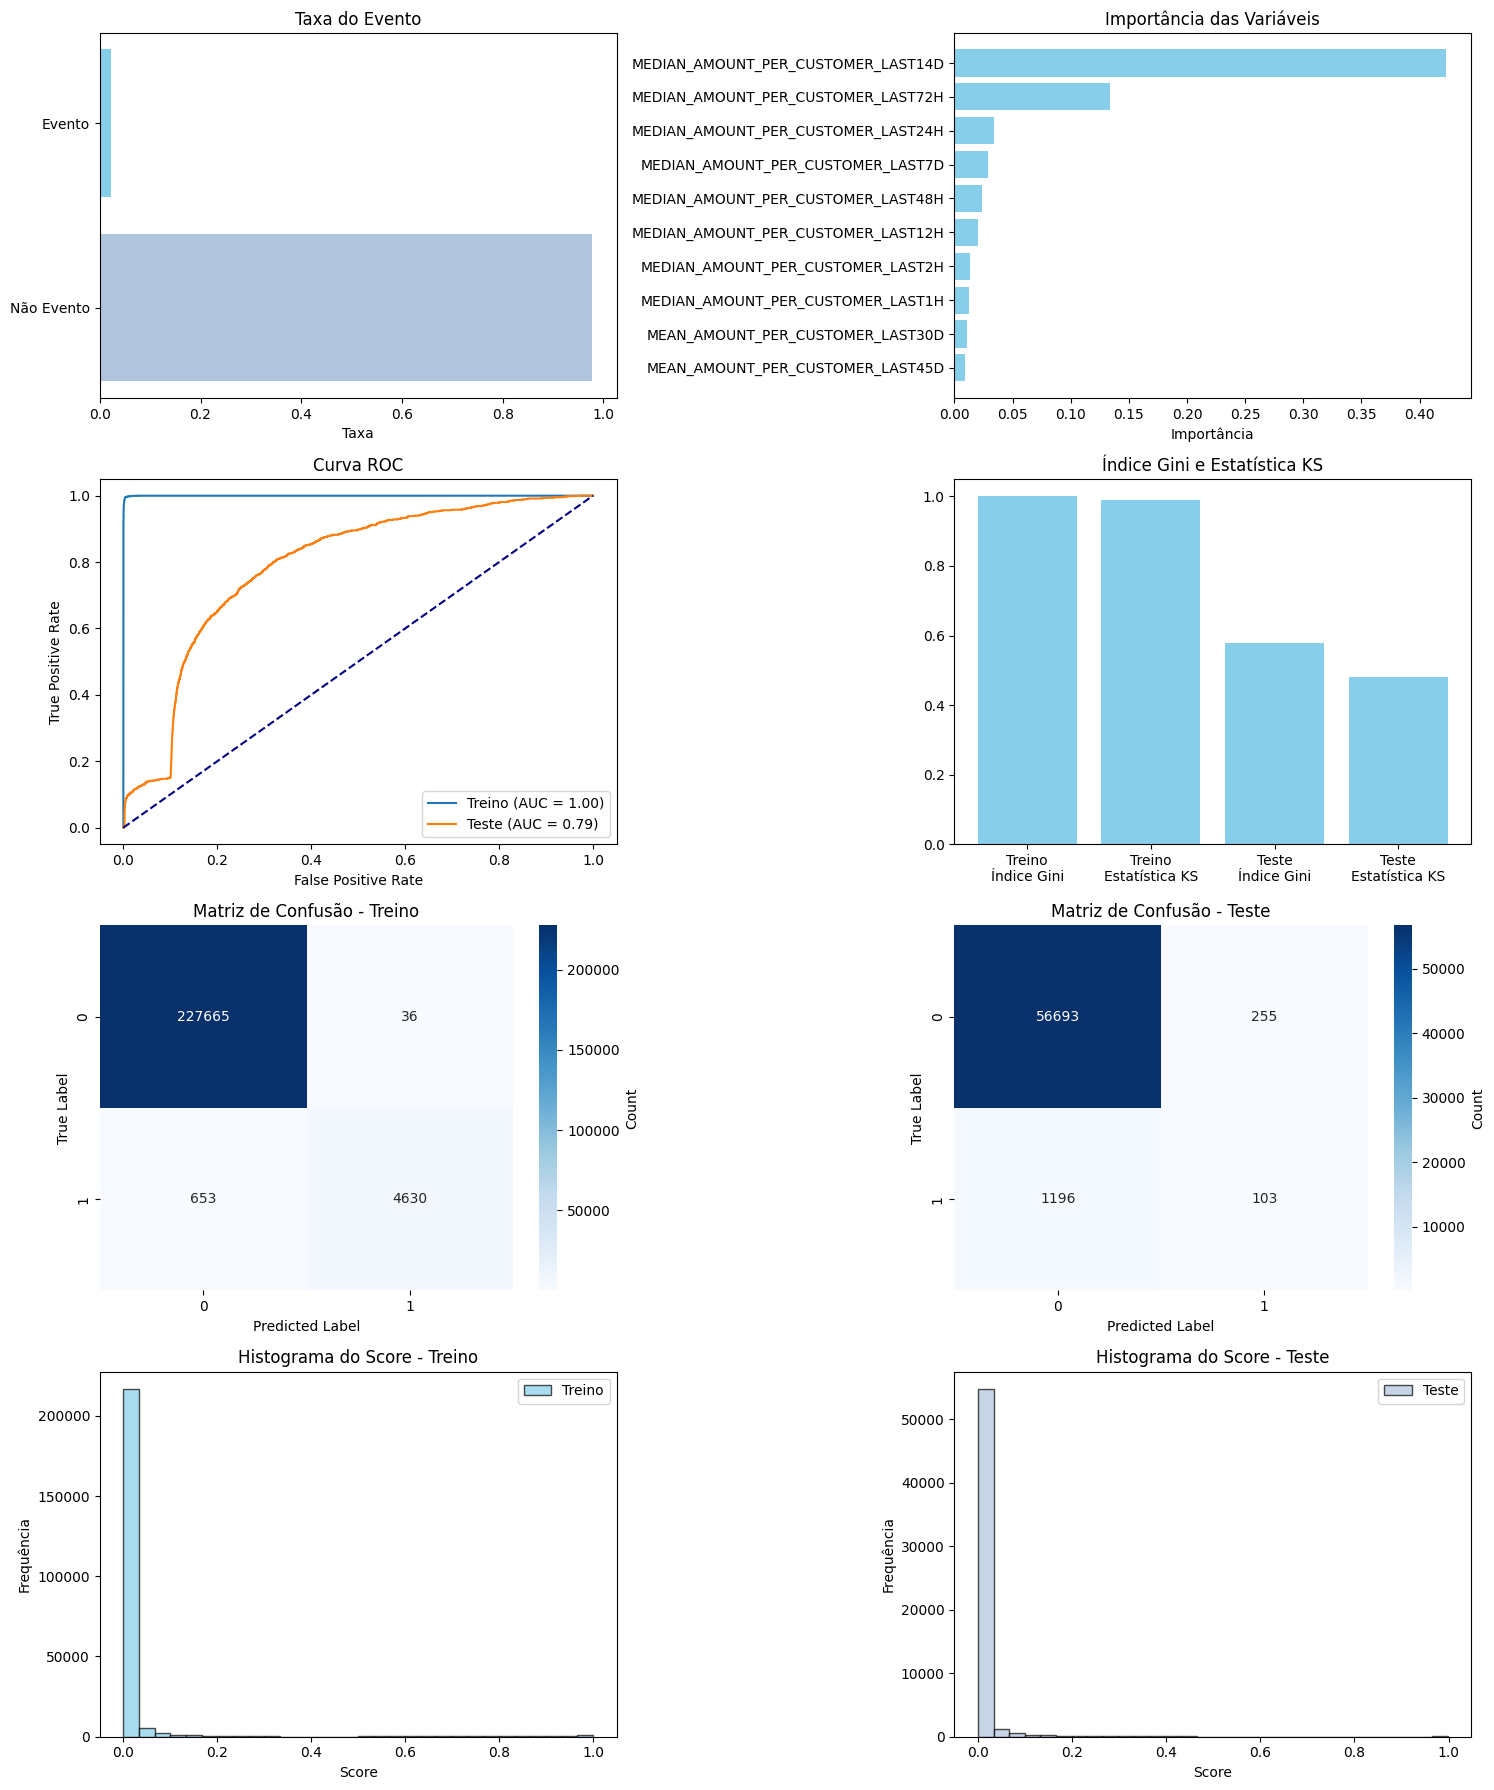

In [40]:
best_params = {
    'n_estimators': 477,
    'max_depth': 10,
    'learning_rate': 0.03353123548872022,
    'subsample': 0.7835590645707871,
    'colsample_bytree': 0.7609302941583845,
    'gamma': 0.005162208886173834,
    'reg_alpha': 0.3177444473094153,
    'reg_lambda': 0.00032509554120250026,
    'min_child_weight': 4
}

features = X_train_processed.columns
# modelo_simplificado_v1_tuned = best_algorithm_tuned = XGBClassifier(random_state=0,**study.best_params)
modelo_simplificado_v1_tuned = best_algorithm_tuned = XGBClassifier(random_state=0,**best_params)
modelo_simplificado_v1_tuned.fit(X_train_processed[vars_selected_v1],y_train)
plot_metrics(best_algorithm_tuned, X_train_processed[vars_selected_v1], y_train, X_test_processed[vars_selected_v1], y_test, features)

y_simplificado_probs_tuned = modelo_simplificado_v1_tuned.predict_proba(X_test_processed[vars_selected_v1])[:,1]

A versão simplificada do modelo, baseada predominantemente em estatísticas de mediana do valor das transações em diferentes janelas temporais, apresentou desempenho igual ou superior às versões anteriores mais complexas. O AUC-ROC próximo de 0,79, aliado a índices Gini e KS elevados no conjunto de teste, evidencia melhora na capacidade de generalização e na ordenação de risco. Esses resultados indicam que a utilização de variáveis robustas ao efeito de outliers contribui significativamente para a estabilidade do modelo. Apesar do recall ainda limitado, o modelo se mostra particularmente adequado para aplicações de priorização e ranking de transações suspeitas, com menor complexidade e maior interpretabilidade.

Também é possível identificar uma mudança na importância das variáveis quando houve a alteração.

# 9.8 Ajuste no threshold

Como o desempenho do modelo não sofreu alterações significativas após a tunagem dos hiperparâmetros, não foi necessário ajustar o threshold de decisão. Caso houvesse mudança no comportamento do modelo, seria preciso recalibrar esse limiar para reavaliar métricas como Precisão e Recall, garantindo um equilíbrio adequado entre identificação de fraudes e controle de falsos positivos.

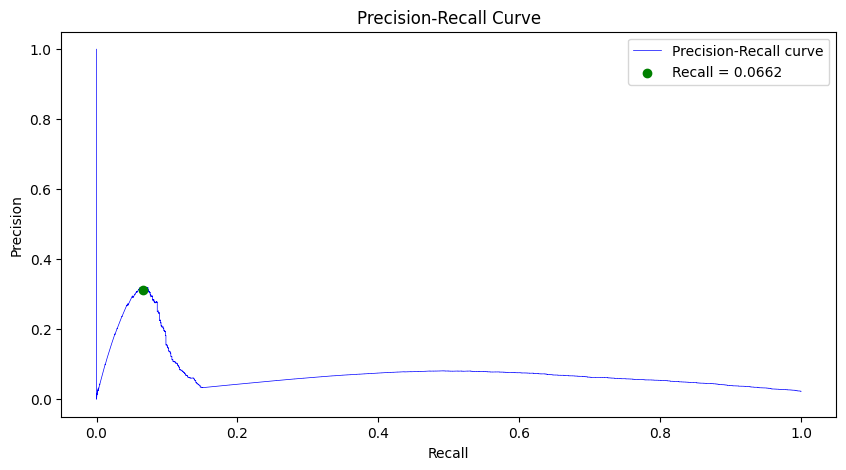

Priorizando a configuração de melhor F1-score:
Melhor F1-score: 0.1400
Threshold correspondente ao F1-score máximo: 3.7249883462209255e-05
Precision: 0.08064516129032258
Recall: 0.5311778290993071
----------------------------------------------------------------------
Priorizando outra configuração com menor recall entretanto um maior precision:
Precision: 0.3116
Recall: 0.0662
Threshold: 0.6466713547706604
F1-score: 0.10919985576074696


In [41]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve

# Supondo que você já tenha os arrays: y_true e y_pred_proba
precision_simplificado_tuned, recall_simplificado_tuned, thresholds_tuned = precision_recall_curve(y_test, y_simplificado_probs_tuned)

# Calcular o F1-score para cada ponto
f1_scores = 2 * (precision_simplificado_tuned * recall_simplificado_tuned) / (precision_simplificado_tuned + recall_simplificado_tuned + 1e-32)

# Encontrar o índice que maximiza o F1-score
best_f1_index = np.argmax(f1_scores)
best_threshold = thresholds_tuned[best_f1_index - 1]  # -1 para alinhar com o tamanho do array de thresholds
best_f1_score = f1_scores[best_f1_index]

# Encontrar o índice onde o recall é aproximadamente 0.0662
recall_target = 0.0662
recall_index = (np.abs(recall_simplificado_tuned - recall_target)).argmin()

# Plot Precision-Recall Curve
plt.figure(figsize=(10, 5))
plt.plot(recall_simplificado_tuned, precision_simplificado_tuned, color='b', lw=0.5, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')

# Marcar o ponto onde recall é 0.0662
plt.scatter(recall_simplificado_tuned[recall_index], precision_simplificado_tuned[recall_index], color='green', label=f'Recall = {recall_target}', zorder=2)

plt.legend()
plt.show()

print('Priorizando a configuração de melhor F1-score:')
print(f'Melhor F1-score: {best_f1_score:.4f}')
print(f'Threshold correspondente ao F1-score máximo: {best_threshold}')
print(f'Precision: {precision_simplificado_tuned[best_f1_index]}')
print(f'Recall: {recall_simplificado_tuned[best_f1_index]}')

f1_score = 2 * (precision_simplificado_tuned[recall_index] * recall_target) / (precision_simplificado_tuned[recall_index] + recall_target + 1e-32)
print(70*'-')
print('Priorizando outra configuração com menor recall entretanto um maior precision:')
print(f'Precision: {precision_simplificado_tuned[recall_index]:.4f}')
print(f'Recall: {recall_simplificado_tuned[recall_index]:.4f}')
print(f'Threshold: {thresholds_tuned[recall_index-1]:.16f}')
print(f'F1-score: {f1_score}')

Os resultados obtidos ao longo do desenvolvimento do modelo indicam uma melhora consistente na capacidade de ordenação de risco, especialmente após a tunagem de hiperparâmetros e a seleção de variáveis mais robustas. Métricas como AUC-ROC, Gini e KS apresentaram evolução no conjunto de teste, confirmando que o modelo consegue distinguir transações mais arriscadas das legítimas.

Por outro lado, a análise da Curva Precision–Recall e do ajuste de threshold evidenciou que o modelo mantém um trade-off acentuado entre precisão e recall, típico de problemas de fraude com bases altamente desbalanceadas. Mesmo com a definição de limiares mais adequados, o recall permanece limitado, o que restringe o uso do modelo como classificador binário automático.

Dessa forma, o ajuste do threshold mostrou-se necessário para compreender cenários operacionais viáveis e alinhar o modelo aos objetivos do negócio. O modelo apresenta melhor desempenho quando utilizado como ferramenta de priorização e ranking de risco, apoiando a seleção de transações suspeitas para análise, em vez de decisões automáticas de bloqueio.

In [43]:

import joblib
from sklearn.pipeline import Pipeline
from google.colab import drive
import os

# Caminho da pasta de modelagem no Drive
MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/03-Modelagem'

# Caminho final do arquivo do modelo
MODEL_PATH = os.path.join(MODEL_DIR, 'pipeline_fraude_final.pkl')

# Criar o pipeline final (pré-processamento + modelo treinado)
pipeline_final = Pipeline([
    ('preprocessor', preprocessor_vars_selected_v1),
    ('model', modelo_simplificado_v1_tuned)
])

# Salvar o pipeline completo
joblib.dump(pipeline_final, MODEL_PATH)

print(f"✅ Pipeline final salvo com sucesso em:\n{MODEL_PATH}")


✅ Pipeline final salvo com sucesso em:
/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/03-Modelagem/pipeline_fraude_final.pkl


In [44]:
MODEL_PATH = '/content/drive/MyDrive/Colab Notebooks/Projetos/Fraud_Prevention/03-Modelagem/pipeline_fraude_final.pkl'
pipeline = joblib.load(MODEL_PATH)

print("Pipeline carregado com sucesso!")


Pipeline carregado com sucesso!


In [45]:
# Exemplo com uma linha do teste
score = pipeline.predict_proba(X_test.iloc[[0]])[:, 1]
print("Score de fraude:", score[0])


Score de fraude: 1.634296e-05
